In [1]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


English Vocabulary Size: 24
Tamil Vocabulary Size: 23

Training started...

Epoch: 50 Loss: 0.0918
Epoch: 100 Loss: 0.0269
Epoch: 150 Loss: 0.0129
Epoch: 200 Loss: 0.0075
Epoch: 250 Loss: 0.0048
Epoch: 300 Loss: 0.0032
Epoch: 350 Loss: 0.0023
Epoch: 400 Loss: 0.0017
Epoch: 450 Loss: 0.0012
Epoch: 500 Loss: 0.0009

Training completed!

--------------------------------
English Input : how are you
Tamil Output  : நீங்கள் எப்படி இருக்கிறீர்கள்
--------------------------------


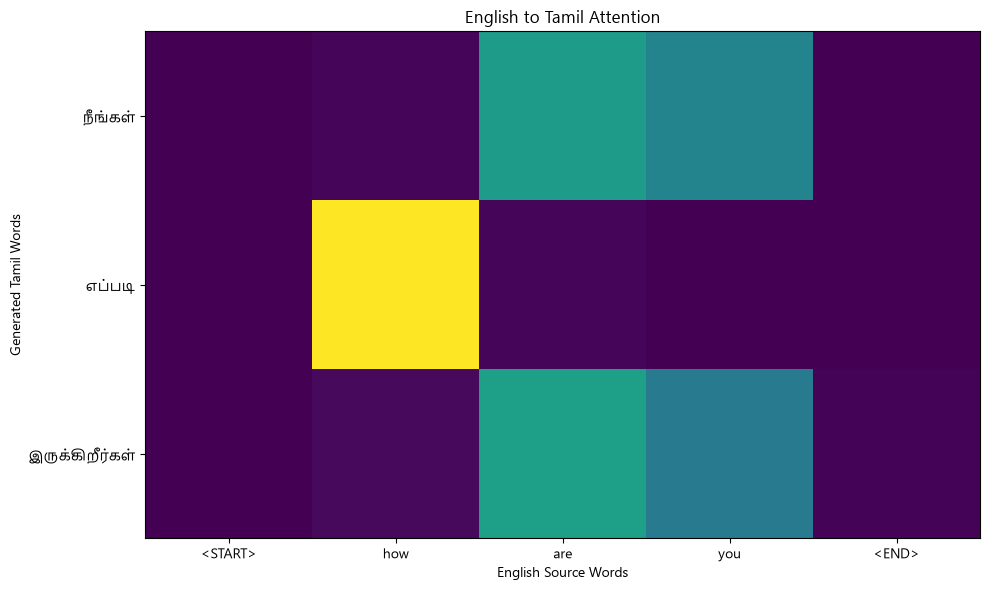

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from matplotlib import rcParams

data = [
    ("how are you", "நீங்கள் எப்படி இருக்கிறீர்கள்"),
    ("what is your name", "உங்கள் பெயர் என்ன"),
    ("good morning", "காலை வணக்கம்"),
    ("thank you", "நன்றி"),
    ("where are you going", "நீங்கள் எங்கே செல்கிறீர்கள்"),
    ("i am fine", "நான் நன்றாக இருக்கிறேன்"),
    ("what are you doing", "நீங்கள் என்ன செய்கிறீர்கள்"),
    ("where do you live", "நீங்கள் எங்கே வசிக்கிறீர்கள்"),
    ("i love tamil", "எனக்கு தமிழ் பிடிக்கும்"),
    ("good evening", "மாலை வணக்கம்")
]

def tokenize(text):
    return text.lower().split()

eng_vocab = {"<PAD>": 0, "<START>": 1, "<END>": 2}
tam_vocab = {"<PAD>": 0, "<START>": 1, "<END>": 2}

for eng, tam in data:
    for word in tokenize(eng):
        if word not in eng_vocab:
            eng_vocab[word] = len(eng_vocab)

    for word in tokenize(tam):
        if word not in tam_vocab:
            tam_vocab[word] = len(tam_vocab)

eng_rev = {v: k for k, v in eng_vocab.items()}
tam_rev = {v: k for k, v in tam_vocab.items()}

print("English Vocabulary Size:", len(eng_vocab))
print("Tamil Vocabulary Size:", len(tam_vocab))

def encode(text, vocab):
    return (
        [vocab["<START>"]] +
        [vocab[w] for w in tokenize(text)] +
        [vocab["<END>"]]
    )

class Encoder(nn.Module):
    def __init__(self, input_size, embedding_size, hidden_size):
        super().__init__()
        self.embedding = nn.Embedding(input_size, embedding_size)
        self.rnn = nn.GRU(
            embedding_size,
            hidden_size,
            batch_first=True
        )

    def forward(self, x):
        embedded = self.embedding(x)
        outputs, hidden = self.rnn(embedded)
        return outputs, hidden

class Attention(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.attention = nn.Linear(
            hidden_size * 2,
            hidden_size
        )
        self.v = nn.Linear(
            hidden_size,
            1,
            bias=False
        )

    def forward(self, hidden, encoder_outputs):
        sequence_length = encoder_outputs.size(1)
        hidden = hidden[-1]
        hidden = hidden.unsqueeze(1)
        hidden = hidden.repeat(
            1,
            sequence_length,
            1
        )

        combined = torch.cat(
            (hidden, encoder_outputs),
            dim=2
        )

        energy = torch.tanh(
            self.attention(combined)
        )

        scores = self.v(energy).squeeze(2)

        weights = torch.softmax(
            scores,
            dim=1
        )

        return weights

class Decoder(nn.Module):
    def __init__(
        self,
        output_size,
        embedding_size,
        hidden_size
    ):
        super().__init__()

        self.embedding = nn.Embedding(
            output_size,
            embedding_size
        )

        self.attention = Attention(
            hidden_size
        )

        self.rnn = nn.GRU(
            embedding_size + hidden_size,
            hidden_size,
            batch_first=True
        )

        self.fc = nn.Linear(
            hidden_size,
            output_size
        )

    def forward(
        self,
        x,
        hidden,
        encoder_outputs
    ):
        embedded = self.embedding(x)

        attention_weights = self.attention(
            hidden,
            encoder_outputs
        )

        context = torch.bmm(
            attention_weights.unsqueeze(1),
            encoder_outputs
        )

        rnn_input = torch.cat(
            (embedded, context),
            dim=2
        )

        output, hidden = self.rnn(
            rnn_input,
            hidden
        )

        prediction = self.fc(output)

        return (
            prediction,
            hidden,
            attention_weights
        )

class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, source, target):
        encoder_outputs, hidden = self.encoder(source)

        outputs = []

        input_word = target[:, 0].unsqueeze(1)

        for t in range(1, target.size(1)):
            output, hidden, attention = self.decoder(
                input_word,
                hidden,
                encoder_outputs
            )

            outputs.append(output)

            input_word = target[:, t].unsqueeze(1)

        return torch.cat(outputs, dim=1)

INPUT_SIZE = len(eng_vocab)
OUTPUT_SIZE = len(tam_vocab)

EMBEDDING_SIZE = 64
HIDDEN_SIZE = 128

encoder = Encoder(
    INPUT_SIZE,
    EMBEDDING_SIZE,
    HIDDEN_SIZE
)

decoder = Decoder(
    OUTPUT_SIZE,
    EMBEDDING_SIZE,
    HIDDEN_SIZE
)

model = Seq2Seq(
    encoder,
    decoder
)

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

criterion = nn.CrossEntropyLoss()

EPOCHS = 500

print("\nTraining started...\n")

for epoch in range(EPOCHS):
    total_loss = 0
    model.train()

    for eng, tam in data:
        source = torch.tensor(
            [encode(eng, eng_vocab)],
            dtype=torch.long
        )

        target = torch.tensor(
            [encode(tam, tam_vocab)],
            dtype=torch.long
        )

        optimizer.zero_grad()

        output = model(
            source,
            target
        )

        loss = criterion(
            output.reshape(
                -1,
                OUTPUT_SIZE
            ),
            target[:, 1:].reshape(-1)
        )

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    if (epoch + 1) % 50 == 0:
        print(
            "Epoch:",
            epoch + 1,
            "Loss:",
            round(total_loss, 4)
        )

print("\nTraining completed!")

def translate(sentence):
    model.eval()

    for word in tokenize(sentence):
        if word not in eng_vocab:
            print("Unknown English word:", word)
            return [], []

    source = torch.tensor(
        [encode(sentence, eng_vocab)],
        dtype=torch.long
    )

    with torch.no_grad():
        encoder_outputs, hidden = model.encoder(source)

    word = torch.tensor(
        [[tam_vocab["<START>"]]],
        dtype=torch.long
    )

    translation = []
    attention_values = []

    for _ in range(20):
        with torch.no_grad():
            output, hidden, attention = model.decoder(
                word,
                hidden,
                encoder_outputs
            )

        prediction = output.argmax(2).item()

        if prediction == tam_vocab["<END>"]:
            break

        translation.append(
            tam_rev[prediction]
        )

        attention_values.append(
            attention.squeeze().numpy()
        )

        word = torch.tensor(
            [[prediction]],
            dtype=torch.long
        )

    return translation, attention_values

sentence = "how are you"

translation, attention = translate(sentence)

print("\n--------------------------------")
print("English Input :", sentence)
print("Tamil Output  :", " ".join(translation))
print("--------------------------------")

if attention:
    rcParams["font.family"] = "Nirmala UI"

    source_words = (
        ["<START>"] +
        tokenize(sentence) +
        ["<END>"]
    )

    plt.figure(figsize=(10, 6))

    plt.imshow(
        attention,
        aspect="auto"
    )

    plt.xticks(
        range(len(source_words)),
        source_words
    )

    plt.yticks(
        range(len(translation)),
        translation
    )

    plt.xlabel("English Source Words")
    plt.ylabel("Generated Tamil Words")
    plt.title("English to Tamil Attention")

    plt.tight_layout()
    plt.show()